In [2]:
from pathlib import Path
import geopandas as gpd
import numpy as np

In [3]:
community_analysis = gpd.read_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/community_area_analysis_v1.geojson")

# PartA: Quick data quality checks
Before plotting and modeling, add a few more derived fields.

You already have:

`crime_count_2025` `crime_density_sqkm` `business_count` `business_density_sqkm` `cta_count` `police_count`

Now add:

`business_per_crime` `log_crime_count` `log_business_count` `log_crime_density` `log_business_density`

This helps because crime and business counts are usually skewed.

In [4]:
community_analysis["business_per_crime"] = community_analysis["business_count"] / community_analysis["crime_count_2025"].replace(0, np.nan)
community_analysis["log_crime_count"] = np.log1p(community_analysis["crime_count_2025"])
community_analysis["log_business_count"] = np.log1p(community_analysis["business_count"])
community_analysis["log_crime_density"] = np.log1p(community_analysis["crime_density_sqkm"])
community_analysis["log_business_density"] = np.log1p(community_analysis["business_density_sqkm"])

## PartB: Descripe plots
This is the next thing you should do.

Make:

- histogram of crime_count_2025

- histogram of crime_density_sqkm

- histogram of business_count

- histogram of business_density_sqkm

These plots will tell you whether the data are heavily skewed, which they almost certainly are.

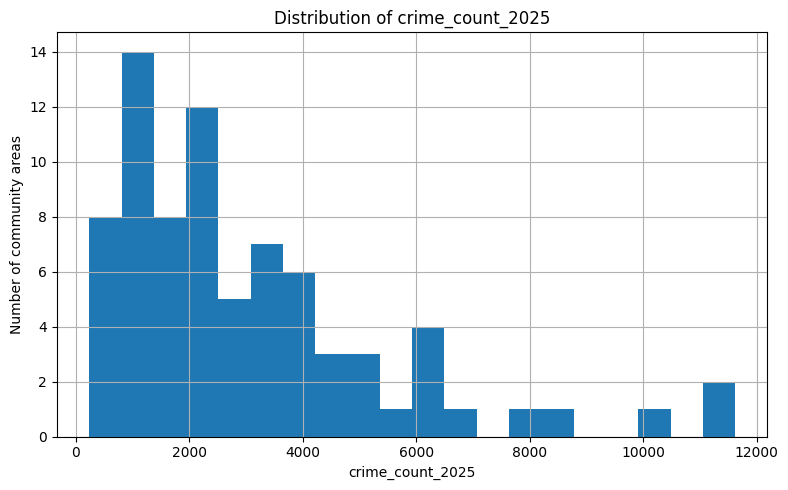

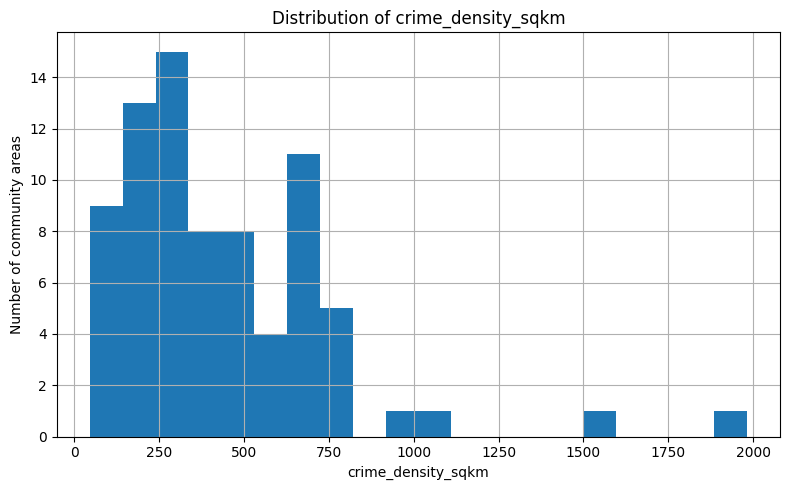

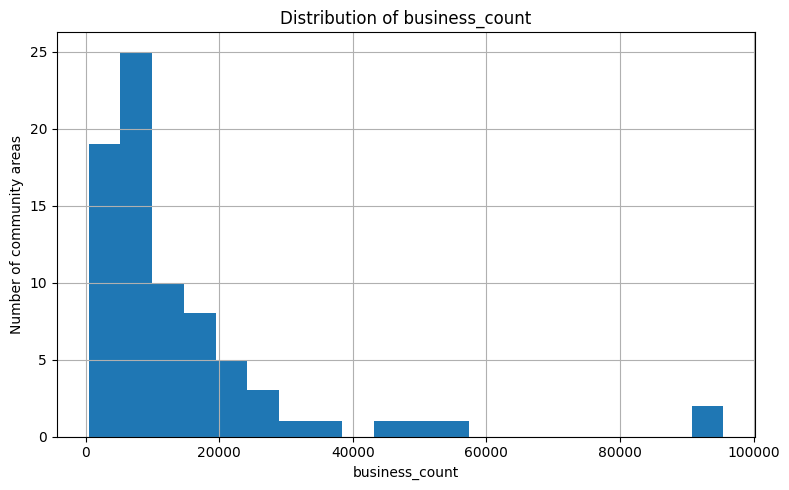

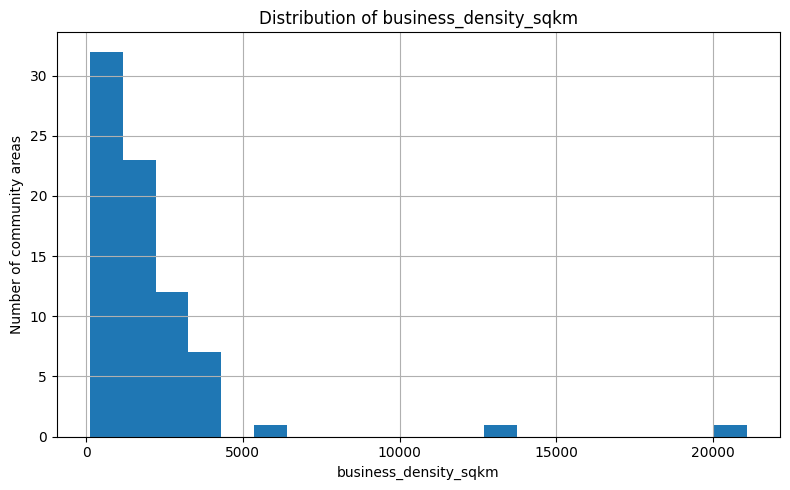

In [5]:
import matplotlib.pyplot as plt

for col in ["crime_count_2025", "crime_density_sqkm", "business_count", "business_density_sqkm"]:
    plt.figure(figsize=(8,5))
    community_analysis[col].hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of community areas")
    plt.tight_layout()
    plt.show()

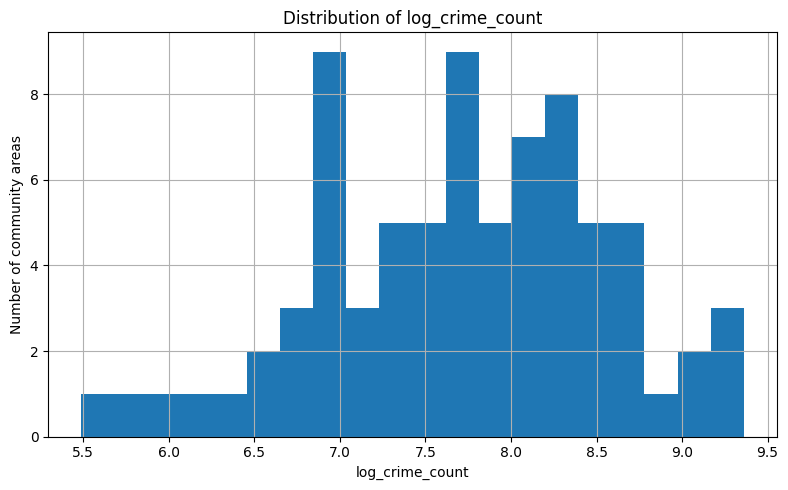

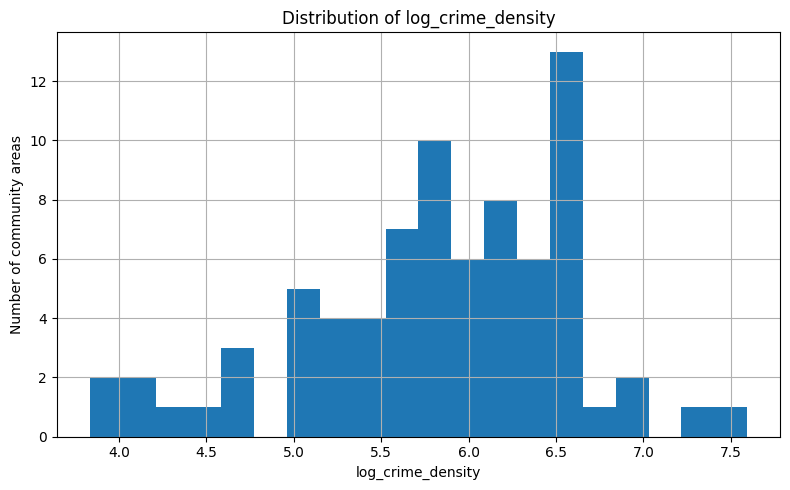

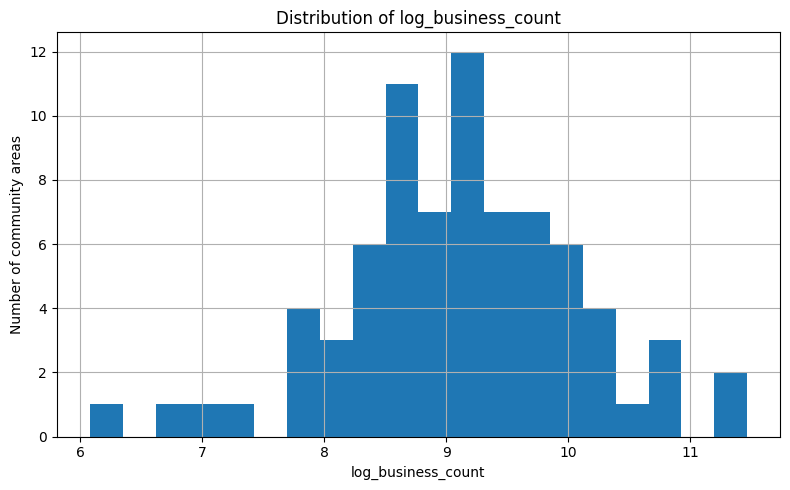

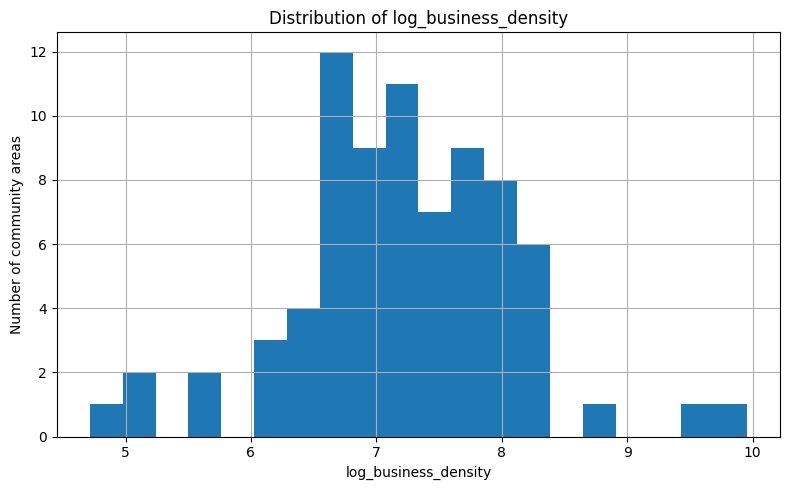

In [6]:
# Then also plot the log versions:
for col in ["log_crime_count", "log_crime_density", "log_business_count", "log_business_density"]:
    plt.figure(figsize=(8,5))
    community_analysis[col].hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of community areas")
    plt.tight_layout()
    plt.show()

## PartC: Initial correlation testing
This is the most important immediate step.

For now, test the relationship between:

- crime count and business count

- crime density and business density

- crime count and CTA count

- crime count and police count

- crime density and CTA count

- crime density and police count

Use both Pearson and Spearman correlations:

- Pearson for linear relationships

- Spearman for rank-based relationships

In [7]:
corr_vars = [
    "crime_count_2025",
    "crime_density_sqkm",
    "business_count",
    "business_density_sqkm",
    "cta_count",
    "police_count"
]

pearson_corr = community_analysis[corr_vars].corr(method="pearson")
spearman_corr = community_analysis[corr_vars].corr(method="spearman")

print("Pearson correlation:")
print(pearson_corr)

print("\nSpearman correlation:")
print(spearman_corr)

Pearson correlation:
                       crime_count_2025  crime_density_sqkm  business_count  \
crime_count_2025               1.000000            0.742281        0.697450   
crime_density_sqkm             0.742281            1.000000        0.640330   
business_count                 0.697450            0.640330        1.000000   
business_density_sqkm          0.497396            0.726444        0.885527   
cta_count                      0.616508            0.705002        0.782959   
police_count                   0.315486            0.201743        0.180805   

                       business_density_sqkm  cta_count  police_count  
crime_count_2025                    0.497396   0.616508      0.315486  
crime_density_sqkm                  0.726444   0.705002      0.201743  
business_count                      0.885527   0.782959      0.180805  
business_density_sqkm               1.000000   0.803551      0.082861  
cta_count                           0.803551   1.000000      0.27

In [21]:
# save the correlation results
# pearson_corr.to_csv("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/tables/pearson_correlation.csv")
# spearman_corr.to_csv("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/tables/spearman_correlation.csv")

This will give you your first evidence of which factors matter most.

My expectation from your preview is:

- strong positive relationship between crime and business activity

- moderate relationship between crime and CTA access

- weaker or ambiguous relationship with police station count

## PartD: Scatter Plots
Do not jump straight into regression. First visualize.

Make these four scatter plots:

- business_count vs crime_count_2025

- business_density_sqkm vs crime_density_sqkm

- cta_count vs crime_count_2025

- police_count vs crime_count_2025

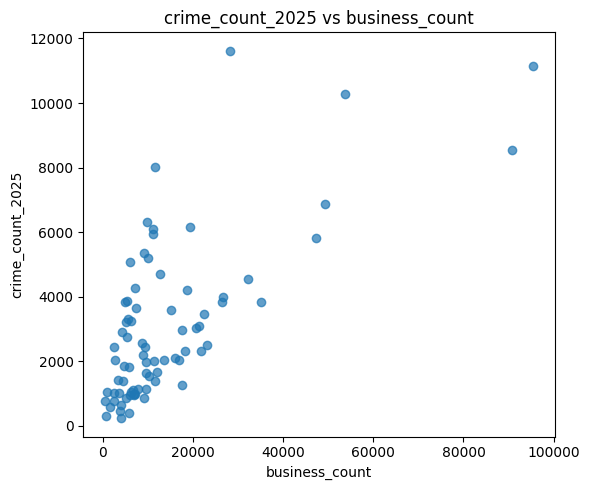

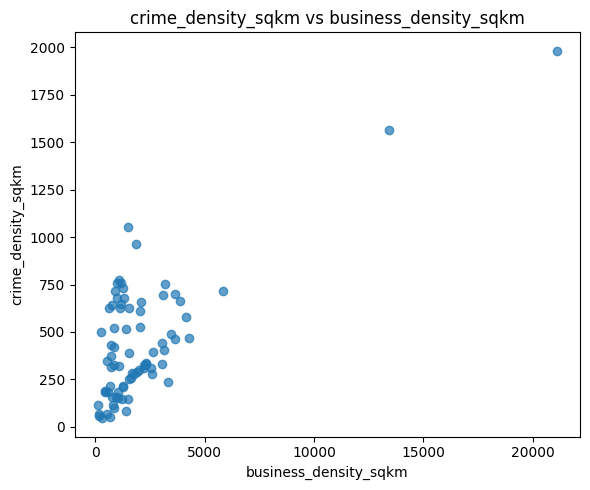

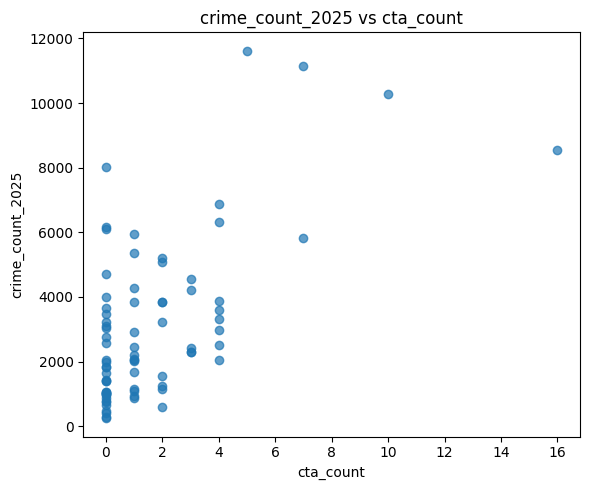

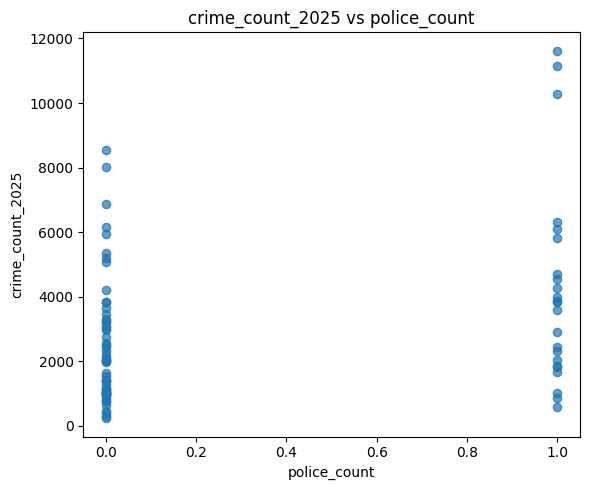

In [8]:
pairs = [
    ("business_count", "crime_count_2025"),
    ("business_density_sqkm", "crime_density_sqkm"),
    ("cta_count", "crime_count_2025"),
    ("police_count", "crime_count_2025")
]

for x, y in pairs:
    plt.figure(figsize=(6,5))
    plt.scatter(community_analysis[x], community_analysis[y], alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

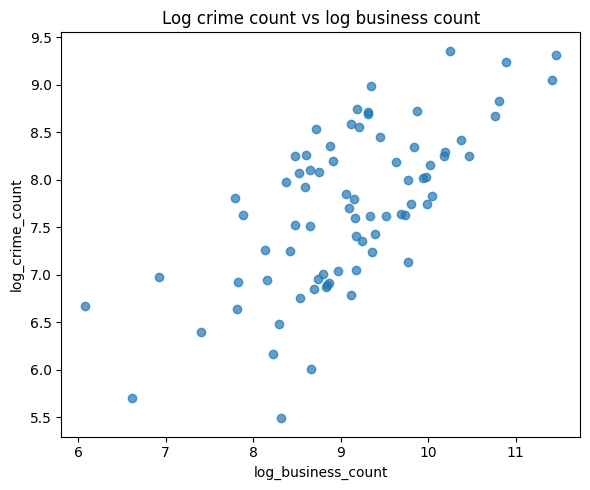

In [9]:
# Also do a log-log version for business and crime:
plt.figure(figsize=(6,5))
plt.scatter(community_analysis["log_business_count"], community_analysis["log_crime_count"], alpha=0.7)
plt.xlabel("log_business_count")
plt.ylabel("log_crime_count")
plt.title("Log crime count vs log business count")
plt.tight_layout()
plt.show()

## PartE: Identify outliers and interesting cases
This is very useful for your interpretation and WebGIS storytelling.

For example:

- high crime, high business: likely downtown core

- high crime, low business: potentially socially vulnerable neighborhoods

- low crime, high business: possibly unusual areas worth explaining

In [10]:
crime_median = community_analysis["crime_count_2025"].median()
biz_median = community_analysis["business_count"].median()

def classify_area(row):
    if row["crime_count_2025"] >= crime_median and row["business_count"] >= biz_median:
        return "High crime / High business"
    elif row["crime_count_2025"] >= crime_median and row["business_count"] < biz_median:
        return "High crime / Low business"
    elif row["crime_count_2025"] < crime_median and row["business_count"] >= biz_median:
        return "Low crime / High business"
    else:
        return "Low crime / Low business"

community_analysis["crime_business_profile"] = community_analysis.apply(classify_area, axis=1)

This field can become a very nice categorical map in ArcGIS Online later.

## Part F: Make your first choropleth maps in python
Before ArcGIS Online, quickly inspect the spatial pattern in Python.

Map:

- crime_count_2025

- crime_density_sqkm

- business_count

- business_density_sqkm

- crime_business_profile

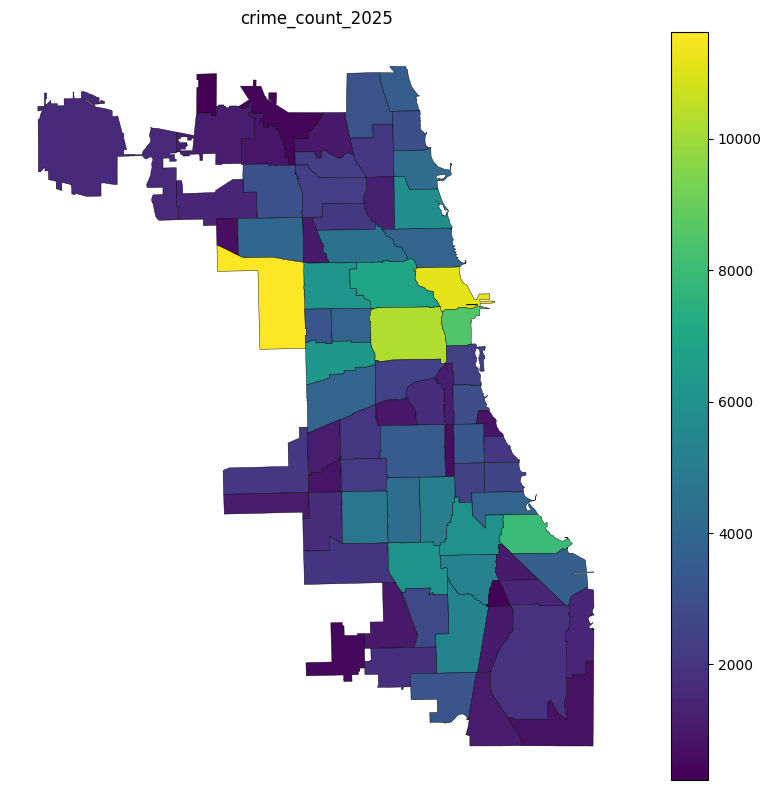

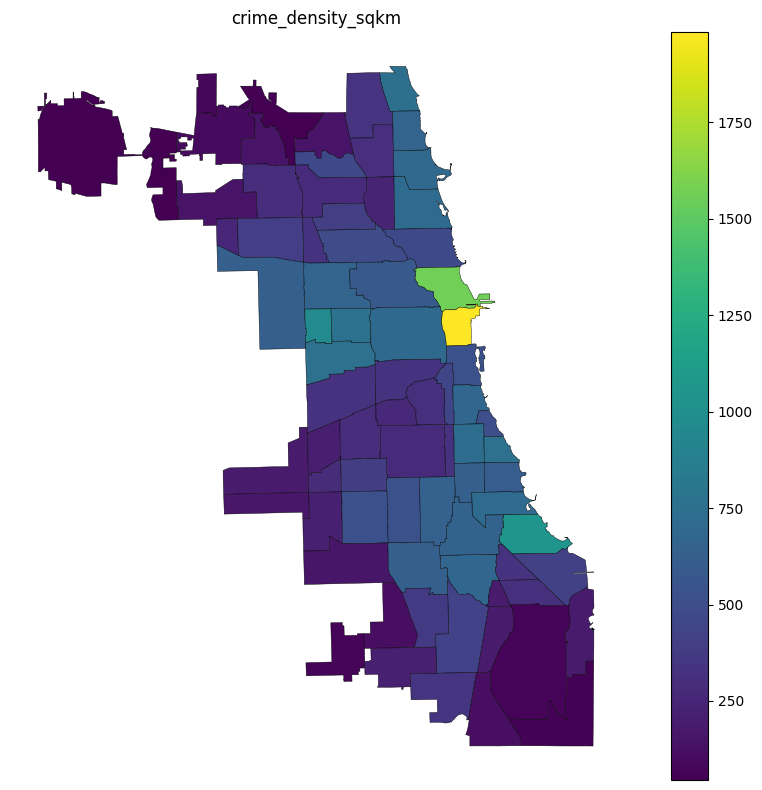

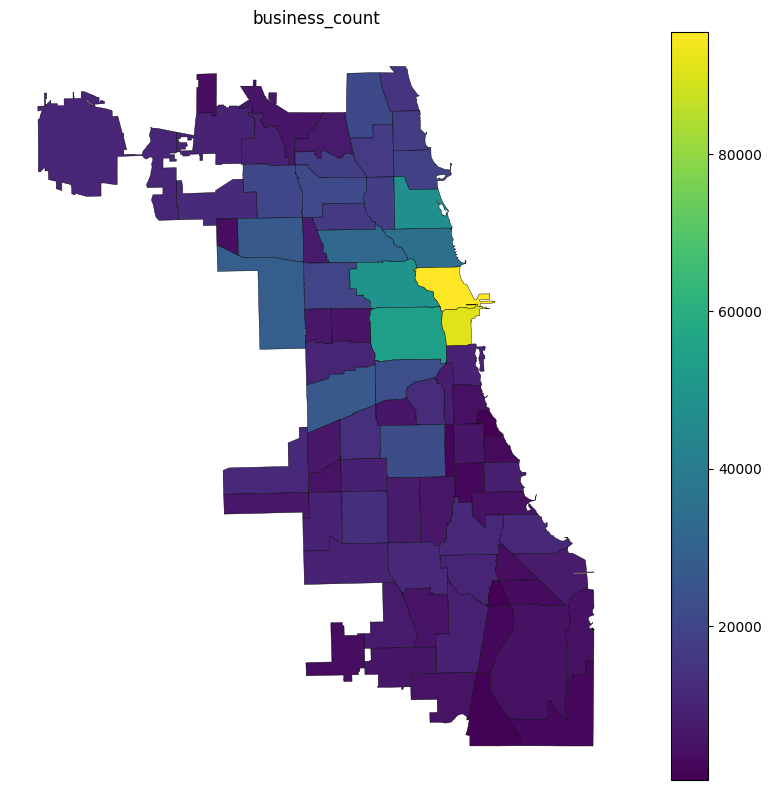

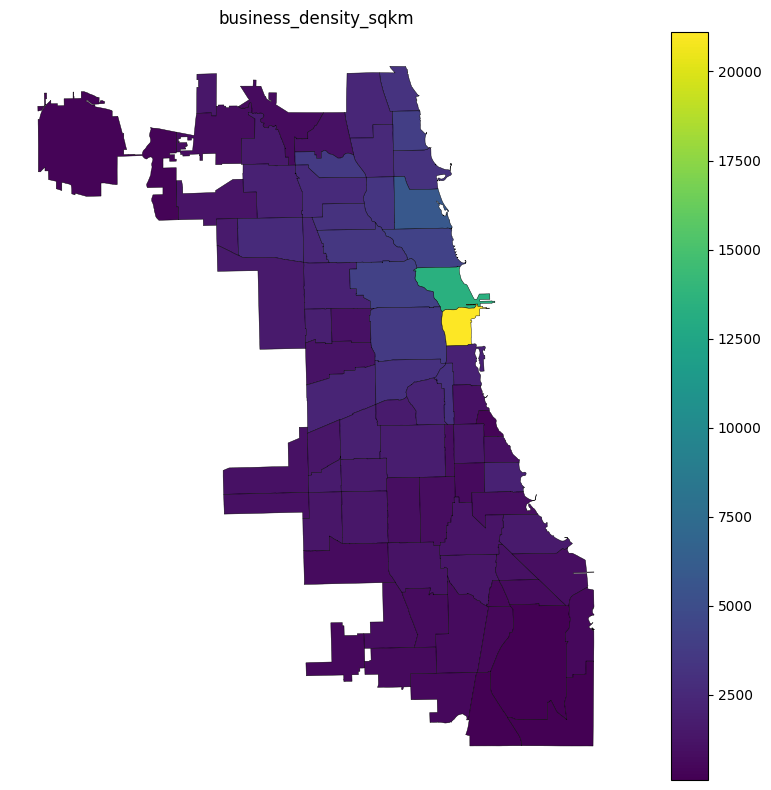

In [11]:
plot_fields = [
    "crime_count_2025",
    "crime_density_sqkm",
    "business_count",
    "business_density_sqkm"
]

for field in plot_fields:
    ax = community_analysis.to_crs("EPSG:4326").plot(
        column=field,
        legend=True,
        figsize=(10,8),
        edgecolor="black",
        linewidth=0.3
    )
    ax.set_title(field)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

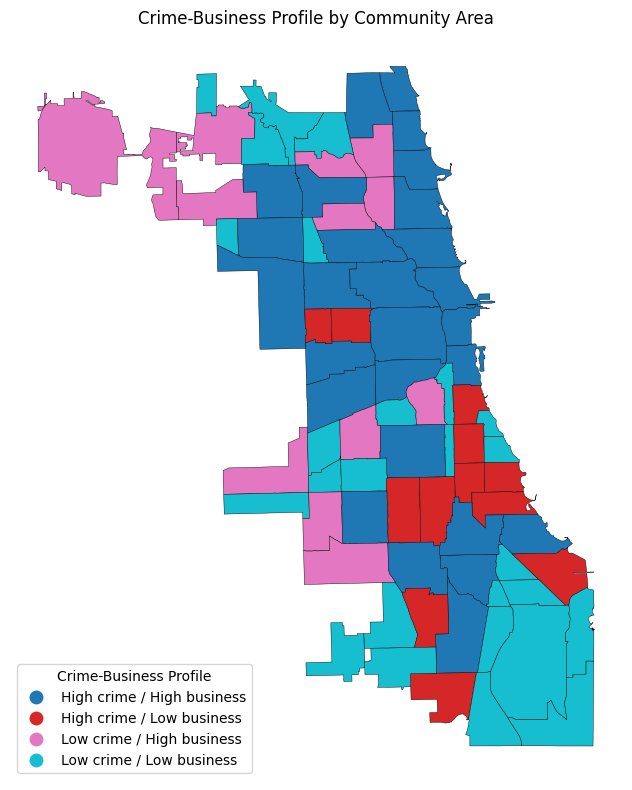

In [16]:
# for the profile map
ax = community_analysis.to_crs("EPSG:4326").plot(
    column="crime_business_profile",
    legend=True,
    figsize=(10,8),
    edgecolor="black",
    linewidth=0.3,
    legend_kwds = {
        "loc": "lower left",
        "title": "Crime-Business Profile",
        "frameon": True
    }
)
ax.set_title("Crime-Business Profile by Community Area")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Outputs/crime_business_profile_map.png",
           dpi=300,
           bbox_inches="tight")
plt.show()

These maps will tell you if the results make spatial sense before publishing.

In [22]:
# Save current finished layers
# community_analysis.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1.gpkg", driver="GPKG")
# community_analysis.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1.geojson", driver="GeoJSON")

In [23]:
# import os

# print(os.path.exists("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1.gpkg"))
# print(os.path.exists("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1.geojson"))
# print(os.path.getsize("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1.gpkg"))
# print(os.path.getsize("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1.geojson"))

## What the correlation are saying
### Main finding 1: crime is strongly accosiated with business activity
This is the clearest signal.
- Crime counts vs business count
- - Pearson: 0.697
  - Spearman: 0.634
- Crime density vs business density
- - Pearson: 0.726
  - Spearman:0.447
Interpretation:

Areas with more businesses tend to have more crime, and areas with denser business activity tend to have denser crime. This fits a plausible place-based explanation: commercial areas attract more movement, interactions, targets, and opportunities.

This is especially visible in places like:
- Loop
- Near North Side
- Near West Side

Therefore,**crime concentration in Chicago appears to be closely related to concentrations of commercial and economic activity**

### Main finding 2: trainsit access also matters
- Crime count vs CTA count
- - Pearson: 0.617
  - Spearmman: 0.491
- Crime density vs CTA count
- - Pearson: 0.705
  - Spearman: 0.536

Interpretation:
Community areas with more CTA stations tend to have higher crime counts and higher crime density. This is not surprising spatially, because transit-rich areas often coincide with:
- high pedestrian flow
- business concentration
- more opportunity structures
- stronger central-city activity

**Transit-accessible areas tend to coincide with higher crime intensity, likely because they concentrate movement and urban activity.**

### Main finding 3: police station count is much weaker

- Crime count vs police count
- - Pearson: 0.315
  - Spearman: 0.289
- Crime density vs police count
- - Pearson: 0.202
  - Spearman: 0.277

Interpretation:
Police station count has only a weak positive relationship with crime. That means it is not a strong explanatory factor in this simple area-level setup.

This is actually reasonable, because:

- there are very few police stations overall

- station presence is a crude proxy for policing

- police facilities are not distributed in proportion to every local crime pattern

- stations may be placed administratively rather than purely by local incident count

So for now:

- keep `police_count` in the dataset,

- but do not rely on it as a major explanatory variable.


### Main finding 4: the data suggest two overlapping but different spatial logics

The difference between Pearson and Spearman is useful.

For example:

- crime_density_sqkm vs business_density_sqkm
- - Pearson: 0.726
  - Spearman: 0.447

This suggests the relationship is fairly strong numerically, but not perfectly monotonic in ranked order. In plain words:

**Some places with very high business density and very high crime density are strongly pulling the linear relationship upward, especially downtown-type areas.**

That means your pattern is likely being influenced by a few major high-intensity places such as:

- Loop
- Near North Side
- Near West Side

This is not a problem. It is actually analytically interesting, because it suggests:

- downtown-style commercial intensity is one crime mechanism,
- but other neighborhoods may have elevated crime for different reasons.

That is exactly the kind of argument that makes your project more nuanced.

## The most important methodological issue revealed by the correlations
This is a clear sign of multicollinearity among your explanatory variables.

Look at these
- business_count vs business_density_sqkm = 0.886
- business_count vs cta_count = 0.783
- business_density_sqkm vs cta_count = 0.804

This means:

- business activity and transit accessibility are strongly entangled
- if you throw all of them into one regression immediately, the coefficients may become unstable or hard to interpret.

So the next modeling step should be careful.

#### What this means in practice

Do not build a model with all raw variables at once.

Instead, use a staged strategy:

- test one factor relationships first
- then build a small multivariable model
- avoid including too many highly correlated variables together

A good first model would be something like:

- dependent variable: `crime_density_sqkm`
- predictors:
- - `business_density_sqkm`
  - `cta_count`
  - maybe `police_count`

But because business density and CTA count are also fairly correlated, you may end up choosing one as the main explanatory variable and treating the other as contextual support.

## What these results mean for your research narrative

Preliminary interpretation [For **Result or Discussion section**]

Chicago crime patterns in 2025 appear to be strongly associated with the spatial concentration of business activity and moderately associated with transit accessibility. These results suggest that crime hotpots are not randomly distributed, but are linked to urban opportunity structures, especially in commercially active and highly connected areas. At the same time, some high-crime neighborhoods do not show extremely high business intensity, indicating that multiple placed-based machanisms may be operating across the city.

## For current evidence, I can make the following findings

Correlation analysis indicates that crime in Chicago is most strongly associated with business activity and transit accessibility. Both crime count and crime density show moderate-to-strong positive relationships with business concentration and CTA station presence, while the relationship with police station count is comparatively weak. These findings suggest that commercially active and highly connected urban areas are more likely to exhibit elevated crime intensity. However, the differences between Pearson and Spearman coefficients imply that the relationship is not uniform across all neighborhoods and may be influenced by a small number of highly urbanized central areas, pointing to multiple spatial mechanisms behind crime concentration.

## Track A: KDE from crime points

Right now you have area-level factor relationships, which is good for explanation.

But your project route is still called:
**Hotspot + explanatory factors**

So you still need a more explicit hotspot layer.

I recommend one of these two:

**Option 1: KDE from crime points**

Pros:

- visually intuitive
- fast
- looks good in WebGIS
- easy to explain

**Option 2: fishnet grid + Getis-Ord Gi***

Pros:

- statistically stronger hotspot definition
- better than administrative boundaries for local hotspot detection
- more impressive academically

My recommendation:

- use KDE for visual hotspot communication
- use community areas for explanatory factor analysis
- optionally add fishnet + Gi* later if time permits

That is the best balance.

## Prepare the crime points specifically for KDE

Before KDE, I recommend creating one dedicated projected crime layer for raster analysis.

Because KDE works better in a projected CRS, save:

- `crime_points_2025_26971.gpkg`

In [1]:
import geopandas as gpd
crime_gdf = gpd.read_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/crime_points_2025.geojson")

In [2]:
crime_proj = crime_gdf.to_crs("EPSG:26971")
crime_proj.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/crime_points_2025_26971.gpkg", driver="GPKG")

In [3]:
community_analysis = gpd.read_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/community_area_analysis_v1.geojson")
community_proj = community_analysis.to_crs("EPSG:26971")
community_proj.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v1_26971.gpkg", driver="GPKG")

## Next use ArcGIS pro for KDE hotsopt workflow

Now you can produce the hotspot surface.

**Best practical route**

Since your project already uses ArcGIS Online and may later use ArcGIS Pro for styling and publishing, the cleanest workflow is:

- prepare the projected crime points in Python

- run Kernel Density in ArcGIS Pro

- export/save the KDE raster as GeoTIFF

- optionally convert or publish it later

This is easier and safer than forcing KDE in Python right now.

In ArcGIS Pro, use:

**Spatial Analyst → Density → Kernel Density**

Input

- `crime_points_2025_26971.gpkg`

Suggested settings

- Population field: none
- Output cell size: start with something like 250 m or 500 m
- Search radius: start with ArcGIS default, then test visually
- Area units: square kilometers if available
- Output raster: crime_kde_2025.tif

**Why 250 m or 500 m?**

- 250 m gives more local detail
- 500 m gives a smoother citywide pattern

For this course project, 250 m is often a good starting point.

## Save KDE outputs for reuse

After running KDE in ArcGIS Pro, save:

- `crime_kde_2025.tif`
- optional styled screenshot/map export for report use
- optional clipped raster to Chicago boundary

If you want, also save a clipped version:

- crime_kde_2025_clipped.tif

That makes web publishing cleaner later.

## Next step in Python: Community-area explanatory analysis outputs to save

Your polygon layer should now become the main explanatory product.

I recommend creating a slightly more polished version before ArcGIS Pro / ArcGIS Online upload.

Add these fields:

- log_crime_count
- log_crime_density
- log_business_count
- log_business_density
- crime_business_profile

Then save as:

- community_area_analysis_v2.gpkg
- community_area_analysis_v2.geojson

In [5]:
import numpy as np

community_analysis["log_crime_count"] = np.log1p(community_analysis["crime_count_2025"])
community_analysis["log_crime_density"] = np.log1p(community_analysis["crime_density_sqkm"])
community_analysis["log_business_count"] = np.log1p(community_analysis["business_count"])
community_analysis["log_business_density"] = np.log1p(community_analysis["business_density_sqkm"])

crime_median = community_analysis["crime_count_2025"].median()
biz_median = community_analysis["business_count"].median()

def classify_area(row):
    if row["crime_count_2025"] >= crime_median and row["business_count"] >= biz_median:
        return "High crime / High business"
    elif row["crime_count_2025"] >= crime_median and row["business_count"] < biz_median:
        return "High crime / Low business"
    elif row["crime_count_2025"] < crime_median and row["business_count"] >= biz_median:
        return "Low crime / High business"
    else:
        return "Low crime / Low business"

community_analysis["crime_business_profile"] = community_analysis.apply(classify_area, axis=1)

# This version will be much more useful for ArcGIS Pro symbology and popups.
community_analysis.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v2.gpkg", driver="GPKG")
community_analysis.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v2.geojson", driver="GeoJSON")

**Suggested symbology choices**
KDE raster

Your current purple ramp is fine. I suggest:

- keep a single-hue sequential ramp
- make low values more transparent if possible
- emphasize the top 2–3 classes visually

That helps the hotspot stand out over the gray basemap.

Community area crime density

Use:

- sequential choropleth
- 5 classes
- natural breaks or quantiles

Business density

Also use:

- sequential choropleth
- a different color family from crime density to avoid confusion

Crime-business profile

Use:

- four distinct categories
- this is a categorical thematic map, not a graduated one


**One small concern from the screenshots**

The KDE raster seems to extend over a fairly large rectangular area with much blank or low-value space outside the core city footprint. That is normal for KDE, but for final presentation I recommend:

- clip the raster to the Chicago boundary
or
- at least clip to the union of community areas

This will make the map much cleaner and more professional in WebGIS.

So if you have not done that yet, do it next in ArcGIS Pro:

- Raster Functions or Extract by Mask / Clip Raster

Output:

- crime_kde_2025_500m_clip.tif

This clipped version is the one I would publish.

**Recommended next sequence**

Please do the following next:

1. clip the 500 m KDE raster to Chicago boundary
2. finalize community_area_analysis_v2
3. create choropleth maps for:
- crime density
- business density
- crime-business profile
4.then we move to ArcGIS Online publishing strategy

Once those are ready, I can help you design:

- which layers to publish,
- which should remain in Pro only,
- and how to structure the final WebGIS app and HTML report around them.

## Track B: move into a first explanatory model

Because you already have the area-level data, the next quantitative step should be:

**Model 1**

Dependent variable:

- `crime_density_sqkm`

Independent variables:

- `business_density_sqkm`
- `cta_count`
- `police_count`

But before that, I would first standardize or log-transform the skewed variables.

A cleaner version would be:

- `log_crime_density`
- `log_business_density`
- `cta_count`
- `police_count`